epoch     0 | loss = 1.424089e+01 | phys = 6.040144e-01 | IC = 1.363688e+00
epoch   500 | loss = 3.161303e-01 | phys = 3.040112e-01 | IC = 1.211915e-03
epoch  1000 | loss = 2.321313e-01 | phys = 2.262254e-01 | IC = 5.905849e-04
epoch  1500 | loss = 2.013820e-01 | phys = 1.970734e-01 | IC = 4.308625e-04
epoch  2000 | loss = 1.934619e-01 | phys = 1.891622e-01 | IC = 4.299698e-04
epoch  2500 | loss = 1.916559e-01 | phys = 1.862820e-01 | IC = 5.373933e-04
epoch  3000 | loss = 1.804058e-01 | phys = 1.768773e-01 | IC = 3.528482e-04
epoch  3500 | loss = 1.750054e-01 | phys = 1.716517e-01 | IC = 3.353720e-04
epoch  4000 | loss = 1.699929e-01 | phys = 1.668172e-01 | IC = 3.175696e-04
epoch  4500 | loss = 1.660525e-01 | phys = 1.627644e-01 | IC = 3.288109e-04
epoch  5000 | loss = 1.625910e-01 | phys = 1.597226e-01 | IC = 2.868437e-04
epoch  5500 | loss = 1.611461e-01 | phys = 1.583555e-01 | IC = 2.790648e-04
epoch  6000 | loss = 1.594105e-01 | phys = 1.567055e-01 | IC = 2.704962e-04
epoch  6500 

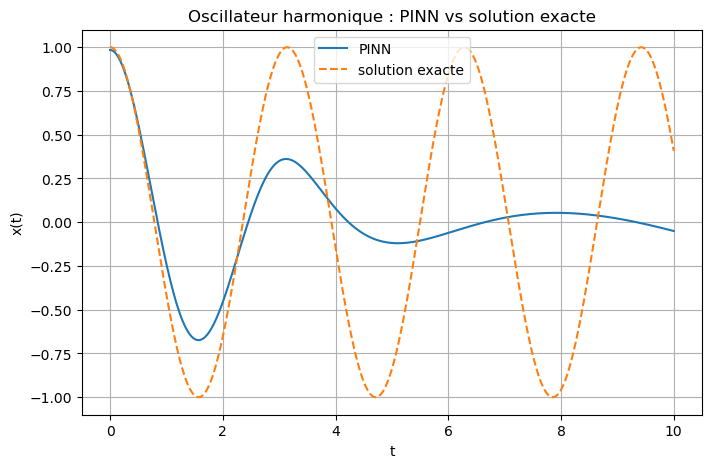

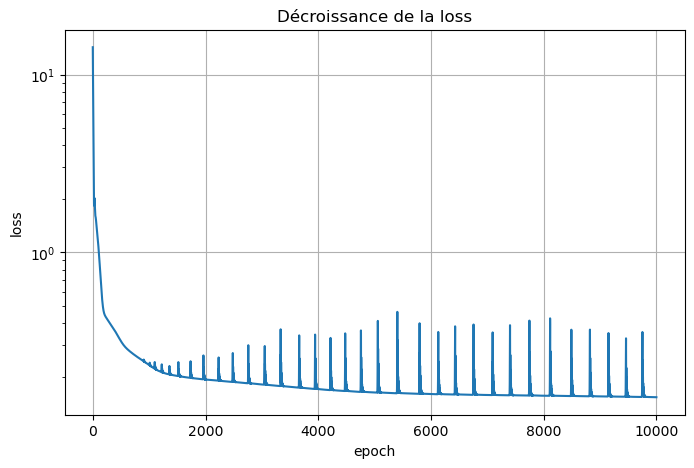

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Paramètres du problème

omega = 2.0
x0 = 1.0
v0 = 0.0
T = 10.0          
N_col = 200       # points de collocation , ne sont pas des données expérimentales. 
                  # Ce sont des points où on va forcer le réseau à respecter l’équation physique.

epochs = 10000    # changer pour avoir un truc mieux
lr = 1e-3

torch.manual_seed(0)  #fixe le hasard pour que les résultats soient reproductibles


# Réseau de neurones
# avec une entrée : t
# avec un sortie : x_theta(t)


class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t):
        return self.net(t)

model = PINN()   # crées ton réseau
optimizer = torch.optim.Adam(model.parameters(), lr=lr) # algorithme d’optimisation , 
# Adam va modifier progressivement les poids du réseau pour réduire la loss !!


# Points de collocation
# Ce sont les points où on impose l'équation

t_col = torch.linspace(0.0, T, N_col).view(-1, 1)
t_col.requires_grad_(True)

# Point initial t = 0
t0 = torch.tensor([[0.0]], requires_grad=True)

loss_history = []


# Ici y'a l'entraînement :

for epoch in range(epochs):
    optimizer.zero_grad()

    # 1) Le réseau prédit x(t)
    x_pred = model(t_col)

    # 2) Dérivée première dx/dt
    dxdt = torch.autograd.grad(
        x_pred,
        t_col,
        grad_outputs=torch.ones_like(x_pred),
        create_graph=True
    )[0]

    # 3) Dérivée seconde d2x/dt2
    d2xdt2 = torch.autograd.grad(
        dxdt,
        t_col,
        grad_outputs=torch.ones_like(dxdt),
        create_graph=True
    )[0]

    # 4) Résidu physique : x'' + omega^2 x = 0
    residual = d2xdt2 + omega**2 * x_pred

    # Loss physique
    loss_phys = torch.mean(residual**2)

    # 5) Conditions initiales
    x0_pred = model(t0)

    v0_pred = torch.autograd.grad(
        x0_pred,
        t0,
        grad_outputs=torch.ones_like(x0_pred),
        create_graph=True
    )[0]

    loss_ic = (x0_pred - x0)**2 + (v0_pred - v0)**2
    loss_ic = loss_ic.mean()

    # 6) Loss totale
    loss = loss_phys + 10.0 * loss_ic

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(
            f"epoch {epoch:5d} | "
            f"loss = {loss.item():.6e} | "
            f"phys = {loss_phys.item():.6e} | "
            f"IC = {loss_ic.item():.6e}"
        )


# Évaluation
t_test = torch.linspace(0.0, T, 1000).view(-1, 1)

with torch.no_grad():
    x_pinn = model(t_test).cpu().numpy().flatten()

t_np = t_test.cpu().numpy().flatten()

# Solution exacte
x_exact = x0 * np.cos(omega * t_np) + (v0 / omega) * np.sin(omega * t_np)


# Affichage des solutions
plt.figure(figsize=(8, 5))
plt.plot(t_np, x_pinn, label="PINN")
plt.plot(t_np, x_exact, "--", label="solution exacte")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Oscillateur harmonique : PINN vs solution exacte")
plt.legend()
plt.grid()
plt.show()


# Affichage de la loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Décroissance de la loss")
plt.grid()
plt.show()